# AI Generated Text Detector — Model Training

**Dataset:** Kaggle `shanegerami/ai-vs-human-text`  
**Task:** Binary text classification (`0 = Human-written`, `1 = AI-generated`)  
**Pipeline:** TF-IDF → SGDClassifier with logistic loss

This notebook covers exploration, cleaning, splitting, feature extraction, model training, evaluation, saving, and prediction tests.

In [1]:
import os, glob, json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
print("Ready.")

Ready.


## 1. Load the Kaggle dataset

In [2]:
candidate_paths = [
    "/kaggle/input/ai-vs-human-text/AI_Human.csv",
    "data/AI_Human.csv",
    "AI_Human.csv",
]

all_csvs = glob.glob("/kaggle/input/**/*.csv", recursive=True) if os.path.exists("/kaggle/input") else []
for p in all_csvs:
    if os.path.basename(p).lower() == "ai_human.csv":
        candidate_paths.insert(0, p)

DATA_PATH = next((p for p in candidate_paths if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "AI_Human.csv was not found. On Kaggle, click Add Input and attach "
        "shanegerami/ai-vs-human-text, then rerun this cell."
    )

print("Dataset path:", DATA_PATH)
df = pd.read_csv(DATA_PATH)
print("Raw shape:", df.shape)
df.head()

Dataset path: /kaggle/input/datasets/shanegerami/ai-vs-human-text/AI_Human.csv
Raw shape: (487235, 2)


,text,generated
0,Cars. Cars have been around since they became ...,0.0
1,Transportation is a large necessity in most co...,0.0
2,"""America's love affair with it's vehicles seem...",0.0
3,How often do you ride in a car? Do you drive a...,0.0
4,Cars are a wonderful thing. They are perhaps o...,0.0


## 2. Explore the dataset and labels

Columns: ['text', 'generated']

Data types:
 text          object
generated    float64
dtype: object

Missing values:
 text         0
generated    0
dtype: int64

Duplicate rows: 0

Label counts:
 generated
0.0    305797
1.0    181438
Name: count, dtype: int64


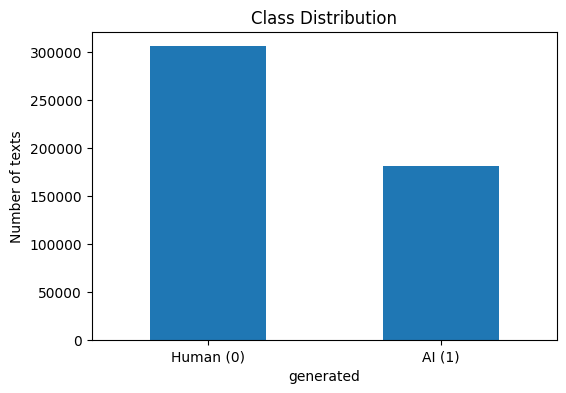

In [3]:
print("Columns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nLabel counts:\n", df["generated"].value_counts(dropna=False).sort_index())

df["generated"].value_counts().sort_index().plot(
    kind="bar", figsize=(6,4), title="Class Distribution"
)
plt.xticks([0,1], ["Human (0)", "AI (1)"], rotation=0)
plt.ylabel("Number of texts")
plt.show()

## 3. Clean the data

In [4]:
work = df[["text","generated"]].copy()
work = work.dropna(subset=["text","generated"])
work["text"] = work["text"].astype(str).str.strip()
work = work[work["text"].str.len() >= 20]
work["generated"] = work["generated"].astype(int)
work = work[work["generated"].isin([0,1])]
work = work.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("Clean shape:", work.shape)
print(work["generated"].value_counts(normalize=True).sort_index().rename("proportion"))

Clean shape: (465243, 2)
generated
0    0.613546
1    0.386454
Name: proportion, dtype: float64


## 4. Optional sampling for a faster Kaggle run

The source dataset is large. The default uses up to 200,000 stratified rows.  
Set `MAX_ROWS = None` if you want to train on every cleaned row.

In [5]:
MAX_ROWS = 200_000

if MAX_ROWS is not None and len(work) > MAX_ROWS:
    work, _ = train_test_split(
        work,
        train_size=MAX_ROWS,
        stratify=work["generated"],
        random_state=RANDOM_STATE,
    )
    work = work.reset_index(drop=True)

print("Rows used:", len(work))
print(work["generated"].value_counts())

Rows used: 200000
generated
0    122709
1     77291
Name: count, dtype: int64


## 5. Train/test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    work["text"],
    work["generated"],
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=work["generated"],
)

print("Train:", len(X_train))
print("Test :", len(X_test))

Train: 160000
Test : 40000


## 6. TF-IDF + classifier pipeline

- TF-IDF converts text into numerical word features.
- Unigrams and bigrams capture single-word and short phrase patterns.
- SGDClassifier with `loss="log_loss"` is a scalable probabilistic linear classifier.
- `class_weight="balanced"` helps with class imbalance.

In [7]:
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        lowercase=True,
        strip_accents="unicode",
        ngram_range=(1,2),
        min_df=3,
        max_df=0.995,
        max_features=60_000,
        sublinear_tf=True,
        dtype=np.float32,
    )),
    ("classifier", SGDClassifier(
        loss="log_loss",
        penalty="l2",
        alpha=1e-5,
        max_iter=50,
        tol=1e-3,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

pipeline

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(dtype=<class 'numpy.float32'>, max_df=0.995,
                                 max_features=60000, min_df=3,
                                 ngram_range=(1, 2), strip_accents='unicode',
                                 sublinear_tf=True)),
                ('classifier',
                 SGDClassifier(alpha=1e-05, class_weight='balanced',
                               loss='log_loss', max_iter=50, n_jobs=-1,
                               random_state=42))])

## 7. Train

In [8]:
pipeline.fit(X_train, y_train)
print("Training complete.")

Training complete.


## 8. Evaluate

In [9]:
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "roc_auc": roc_auc_score(y_test, y_prob),
}

metrics_df = pd.DataFrame([metrics]).T.rename(columns={0:"score"})
display(metrics_df.style.format("{:.4f}"))

print("\nClassification report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Human-written","AI-generated"],
    digits=4
))

,score
accuracy,0.9966
precision,0.9982
recall,0.9930
f1,0.9956
roc_auc,0.9997



Classification report:

               precision    recall  f1-score   support

Human-written     0.9956    0.9989    0.9972     24542
 AI-generated     0.9982    0.9930    0.9956     15458

     accuracy                         0.9966     40000
    macro avg     0.9969    0.9959    0.9964     40000
 weighted avg     0.9966    0.9966    0.9966     40000



## 9. Confusion matrix

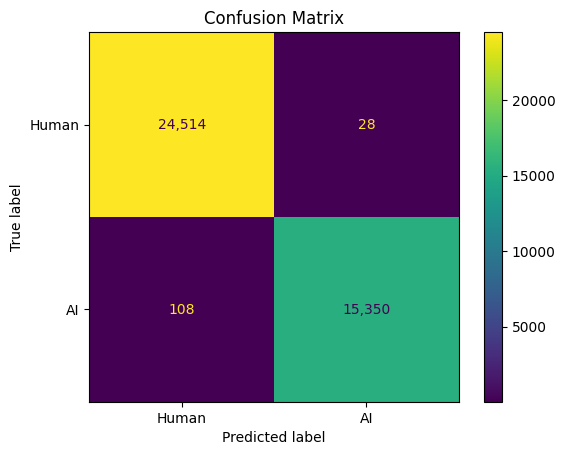

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Human","AI"])
disp.plot(values_format=",d")
plt.title("Confusion Matrix")
plt.show()

## 10. Example predictions from the test set

In [11]:
results = pd.DataFrame({
    "text": X_test.reset_index(drop=True).head(10),
    "true_label": y_test.reset_index(drop=True).head(10),
})

probs = pipeline.predict_proba(results["text"])
results["predicted_label"] = pipeline.predict(results["text"])
results["confidence"] = probs.max(axis=1)
results["prediction_name"] = results["predicted_label"].map({
    0:"Human-written",
    1:"AI-generated"
})

display(results[[
    "true_label","predicted_label","prediction_name","confidence","text"
]])

,true_label,predicted_label,prediction_name,confidence,text
0,0,0,Human-written,0.996608,Changing The Future\n\nTimes are changing. Dri...
1,1,1,AI-generated,0.995225,The United States is a nation in love with its...
2,1,1,AI-generated,0.998925,Title: The Negative Consequences of Career Ide...
3,1,1,AI-generated,0.935479,"In today's world, it's hard to find an adverti..."
4,0,0,Human-written,0.995183,"GtALLLLLL!!!!\n\nWhether it's playing sports, ..."
5,1,1,AI-generated,0.998313,"Dear Senator, \n\nI am writing to express my v..."
6,0,0,Human-written,0.862931,How would sou feel if the computer sou were us...
7,0,0,Human-written,0.975882,Operating a motor vehicle while on your cell p...
8,0,0,Human-written,0.997417,Have you ever wondered the emotional expressio...
9,0,0,Human-written,0.982733,"Today, technology is advanced enough to create..."


## 11. Save the complete trained pipeline

In [12]:
OUTPUT_DIR = Path("/kaggle/working/models") if os.path.exists("/kaggle/working") else Path("models")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = OUTPUT_DIR / "ai_text_detector.joblib"
joblib.dump(pipeline, MODEL_PATH, compress=3)

print("Saved model to:", MODEL_PATH)
print("Size (MB):", round(MODEL_PATH.stat().st_size / 1024**2, 2))

Saved model to: /kaggle/working/models/ai_text_detector.joblib
Size (MB): 0.93


## 12. Reload the saved model and test it

In [13]:
loaded_model = joblib.load(MODEL_PATH)

def predict_text(text):
    pred = int(loaded_model.predict([text])[0])
    probs = loaded_model.predict_proba([text])[0]
    classes = list(loaded_model.classes_)
    human_p = float(probs[classes.index(0)])
    ai_p = float(probs[classes.index(1)])

    return {
        "label": "AI-generated" if pred == 1 else "Human-written",
        "prediction": pred,
        "confidence": round(max(human_p, ai_p), 4),
        "human_probability": round(human_p, 4),
        "ai_probability": round(ai_p, 4),
    }

print(predict_text(
    "I missed the bus this morning, so I walked to campus and grabbed coffee on the way."
))
print(predict_text(
    "Artificial intelligence provides organizations with powerful tools for automation, optimization, and data-driven decision making across many industries."
))

{'label': 'AI-generated', 'prediction': 1, 'confidence': 0.9229, 'human_probability': 0.0771, 'ai_probability': 0.9229}
{'label': 'AI-generated', 'prediction': 1, 'confidence': 0.9808, 'human_probability': 0.0192, 'ai_probability': 0.9808}


## 13. Save metrics

In [14]:
metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, "w") as f:
    json.dump({k: round(float(v), 6) for k,v in metrics.items()}, f, indent=2)

print("Saved:", metrics_path)

Saved: /kaggle/working/models/metrics.json


## 14. Final step

From Kaggle **Output**, download `models/ai_text_detector.joblib`.  
Put it in the local project folder under `models/`, then run:

`uvicorn main:app --reload`